In [51]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [52]:
# Load the dataset
file_path = 'Data/Final/San_Jose___Jackson.csv'
data = pd.read_csv(file_path)

# Drop irrelevant columns
cols_to_drop = ['latitude','longitude','city']
data.drop(cols_to_drop, axis=1, inplace=True)

# Check the first few rows to see the data structure
print(data.head())

# Define the columns to be used for the drought prediction model
cols = ['aqi', 'temperature_2m', 'relative_humidity_2m', 
        'wind_speed_10m', 'pressure_msl', 'precipitation', 'cloud_cover']
data = data[cols]

# Check for missing values and fill or drop them if necessary
data.isnull().sum()  # This will show how many missing values there are per column

# Fill missing values with the column mean (or use other imputation strategies if required)
data.fillna(data.mean(), inplace=True)


         date  pm2.5  ozone    aqi  temperature_2m  relative_humidity_2m  \
0  2014-01-01   60.4  0.015  154.0       10.993118             42.393568   
1  2014-01-02   33.0  0.010   96.0       12.511500             41.723330   
2  2014-01-03   32.6  0.010   95.0       14.938583             37.342059   
3  2014-01-04   26.4  0.015   83.0       14.390667             40.825293   
4  2014-01-05   19.5  0.018   70.0       11.257333             47.339449   

   wind_speed_10m  pressure_msl  precipitation  cloud_cover  
0        8.427079   1021.341176            0.0    31.823529  
1        8.878908   1019.933333            0.0    44.041667  
2        7.806972   1017.075000            0.0    92.541667  
3        6.490594   1015.345833            0.0    55.375000  
4        7.805876   1018.612500            0.0     0.000000  


In [53]:
data['temp_rolling_avg'] = data['temperature_2m'].rolling(window=7).mean()
data['precip_rolling_avg'] = data['precipitation'].rolling(window=7).mean()

# Cumulative precipitation
data['precip_cumulative'] = data['precipitation'].cumsum()

# We may also want to add a column indicating drought conditions based on specific thresholds
# Here, we define drought as a period with very low precipitation and very high temperature
# Adjust these thresholds based on domain knowledge or data analysis
data['drought'] = (data['precipitation'] < 5) & (data['temperature_2m'] > 35)  # Example threshold

# Drop any NaN values that may have been introduced by rolling averages
data.dropna(inplace=True)

In [54]:
scaler = MinMaxScaler()

# Scale the features
data_scaled = scaler.fit_transform(data[cols])

# Check the scaled data
print(data_scaled[:5])

[[0.41626794 0.3320269  0.3849853  0.14213057 0.66627572 0.
  0.91416667]
 [0.33971292 0.22031206 0.83140448 0.30466684 0.67277961 0.00146199
  0.77916667]
 [0.15789474 0.19596491 0.87647913 0.31913082 0.6983687  0.
  0.79916667]
 [0.29186603 0.1831975  0.72575061 0.37924796 0.7190532  0.
  0.71916667]
 [0.30143541 0.26997135 0.67298949 0.27418928 0.69122508 0.
  0.99875   ]]


In [55]:
def create_sequences(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i + look_back])  # Create sequences of 'look_back' length
        y.append(data[i + look_back, -1])  # The last column (drought) is the target
    return np.array(X), np.array(y)

look_back = 30  # Use the last 30 days of data to predict the next day

# Create sequences for the features (X) and the target variable (y)
X, y = create_sequences(data_scaled, look_back)

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes
print(X_train.shape, y_train.shape)

(3260, 30, 7) (3260,)


In [56]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))  # Dropout for regularization
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1, activation='sigmoid'))  # Sigmoid for binary classification (drought/no drought)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy * 100:.2f}%")

Epoch 1/10


/Users/KumarVeena/Documents/Prathik/droughtprediction/drought/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.0430 - loss: 0.6634 - val_accuracy: 0.0466 - val_loss: 0.6574
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0468 - loss: 0.6423 - val_accuracy: 0.0478 - val_loss: 0.6556
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0485 - loss: 0.6337 - val_accuracy: 0.0551 - val_loss: 0.6412
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0540 - loss: 0.6211 - val_accuracy: 0.0527 - val_loss: 0.6324
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0484 - loss: 0.6070 - val_accuracy: 0.0576 - val_loss: 0.6204
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0503 - loss: 0.6062 - val_accuracy: 0.0576 - val_loss: 0.6131
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0469 - loss: 0.6027 - val_accuracy: 0.0576 - val_loss: 0.6131
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0528 - loss: 0.5962 - val_accuracy: 0.056

In [57]:
# Ensure y_test is binary (0 or 1)
y_test_binary = (y_test > 0.5).astype(int)  # Convert continuous y_test to binary if needed

# Predict drought conditions on the test set
y_pred = model.predict(X_test)

# Convert the predictions to binary (drought or no drought)
y_pred_binary = (y_pred > 0.5).astype(int)

# Print the classification report
from sklearn.metrics import classification_report
print(classification_report(y_test_binary, y_pred_binary))



26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step 
              precision    recall  f1-score   support

           0       0.73      0.87      0.79       498
           1       0.70      0.50      0.58       318

    accuracy                           0.72       816
   macro avg       0.72      0.68      0.69       816
weighted avg       0.72      0.72      0.71       816



Last precipitation value: 0.0

Correlation of Weather Features with Drought Condition:
drought                 1.000000
temperature_2m          0.418012
aqi                     0.154403
wind_speed_10m          0.000743
precipitation          -0.051855
cloud_cover            -0.141988
pressure_msl           -0.177981
relative_humidity_2m   -0.369800
Name: drought, dtype: float64


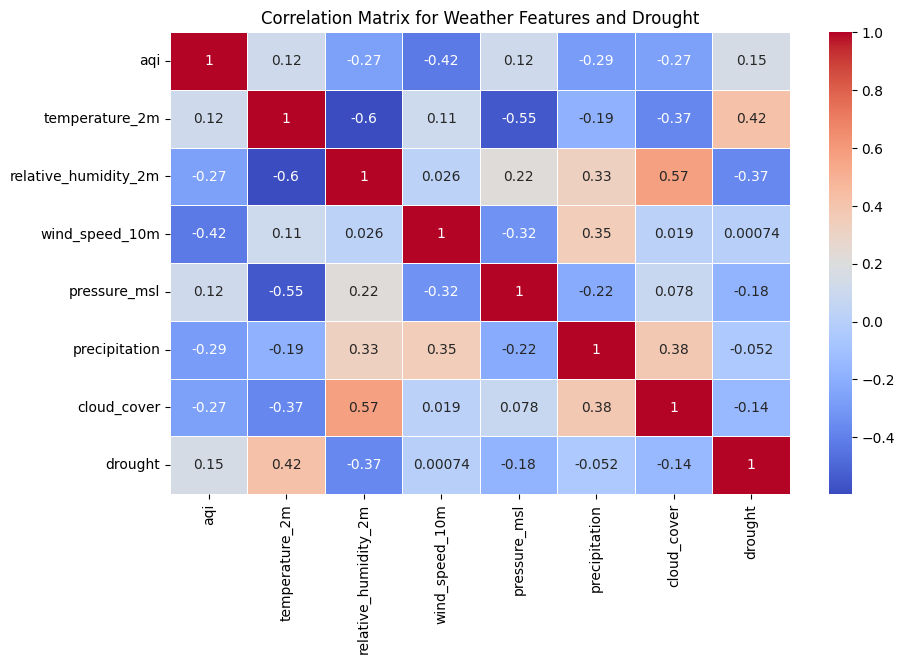


Predicted Drought Conditions for the Next 30 Days:
      Date  Predicted Drought
2025-04-05                  0
2025-04-06                  0
2025-04-07                  0
2025-04-08                  0
2025-04-09                  0
2025-04-10                  0
2025-04-11                  0
2025-04-12                  0
2025-04-13                  0
2025-04-14                  0
2025-04-15                  0
2025-04-16                  0
2025-04-17                  0
2025-04-18                  0
2025-04-19                  0
2025-04-20                  0
2025-04-21                  0
2025-04-22                  0
2025-04-23                  0
2025-04-24                  0
2025-04-25                  0
2025-04-26                  0
2025-04-27                  0
2025-04-28                  0
2025-04-29                  0
2025-04-30                  0
2025-05-01                  0
2025-05-02                  0
2025-05-03                  0
2025-05-04                  0


In [58]:
# Ensure all required columns exist
missing_features = [col for col in cols if col not in data.columns]
if missing_features:
    raise KeyError(f"Missing required columns: {missing_features}")

# Define drought condition (Assume based on precipitation threshold)
data['drought'] = ((data['precipitation'] < 0.2) & (data['temperature_2m'] > 25)).astype(int)

print("Last precipitation value:", data['precipitation'].iloc[-1])
# === Correlation Matrix ===
correlation_matrix = data[cols + ['drought']].corr()

# Display correlation with drought condition
print("\nCorrelation of Weather Features with Drought Condition:")
print(correlation_matrix['drought'].sort_values(ascending=False))

# Plot correlation matrix as heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix for Weather Features and Drought")
plt.show()

# === Train Model ===
train_size = int(len(data) * 0.8)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]


model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(train_data[cols], train_data['drought'])

# === Predict Future Drought Conditions ===
today = datetime.today()
future_dates = [(today + timedelta(days=i)).strftime('%Y-%m-%d') for i in range(1, 31)]

# Use last known values as reference for future predictions
latest_weather = data.iloc[-1][cols]
future_weather_data = pd.DataFrame([latest_weather] * 30, index=future_dates, columns=cols)

# Predict drought conditions for the next 30 days
y_pred_proba_future = model.predict_proba(future_weather_data)[:, 1]  # Probability output
y_pred_binary_future = (y_pred_proba_future > 0.5).astype(int)  # Convert to binary (0 or 1)

# Create a DataFrame for results
results_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted Drought': y_pred_binary_future
})

# Print results in table format
print("\nPredicted Drought Conditions for the Next 30 Days:")
print(results_df.to_string(index=False))



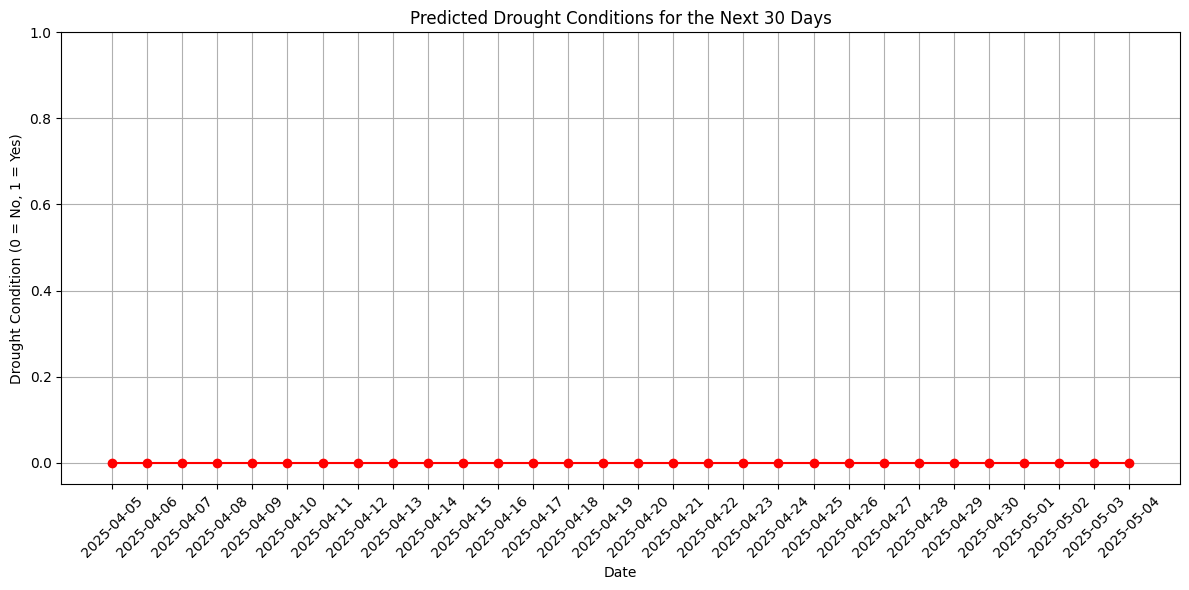

In [59]:
# === Plot Future Drought Predictions ===
plt.figure(figsize=(12, 6))
plt.plot(future_dates, y_pred_binary_future, label='Predicted Drought', color='r', marker='o')
plt.ylim(-0.05, 1)
# Customize the plot
plt.title('Predicted Drought Conditions for the Next 30 Days')
plt.xlabel('Date')
plt.ylabel('Drought Condition (0 = No, 1 = Yes)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
